<a href="https://colab.research.google.com/github/asvinnkumar/Assessment_3_Aswin_Kumar-/blob/main/Assessment_3_Aswin_Kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/Data Science Main/Intermediate Assessment /train_LZdllcl.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Data Science Main/Intermediate Assessment /test_2umaH9m.csv')

In [ ]:
train_df.shape

(54808, 14)

In [ ]:
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
train_df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')

In [ ]:
train_df.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [ ]:
train_df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [ ]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [ ]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [ ]:
train_df['education'].mode()[0]

"Bachelor's"

In [ ]:
train_df['education'] = train_df['education'].fillna(train_df['education'].mode()[0])

In [ ]:
train_df['previous_year_rating'].median()

3.0

In [ ]:
train_df['previous_year_rating'] = train_df['previous_year_rating'].fillna(train_df['previous_year_rating'].median())

In [ ]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

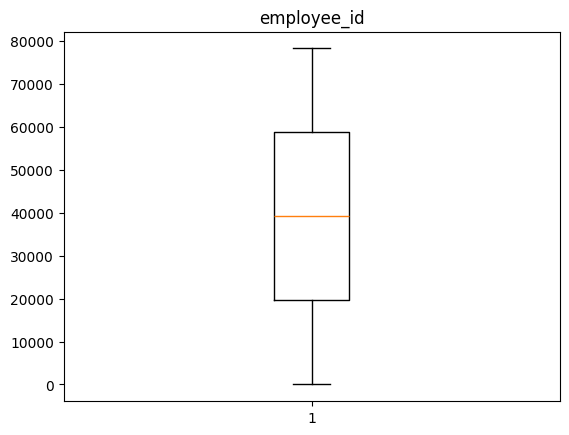

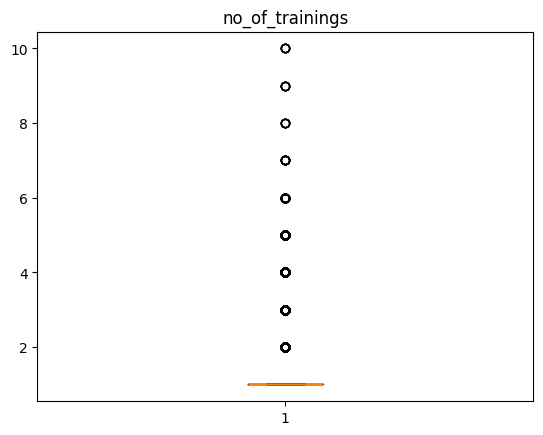

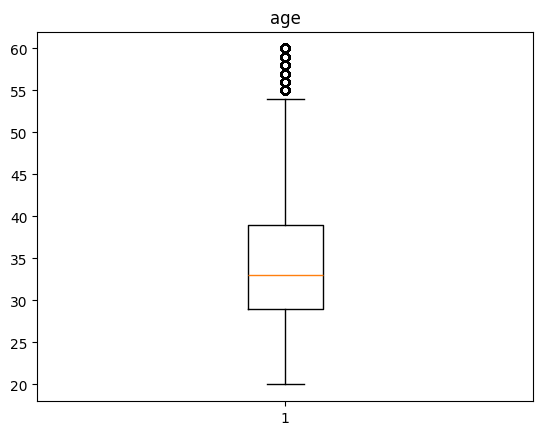

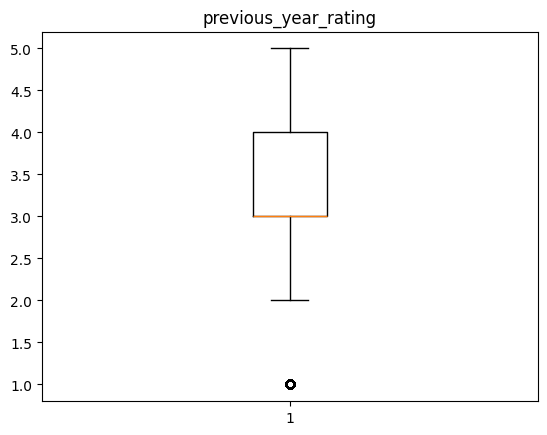

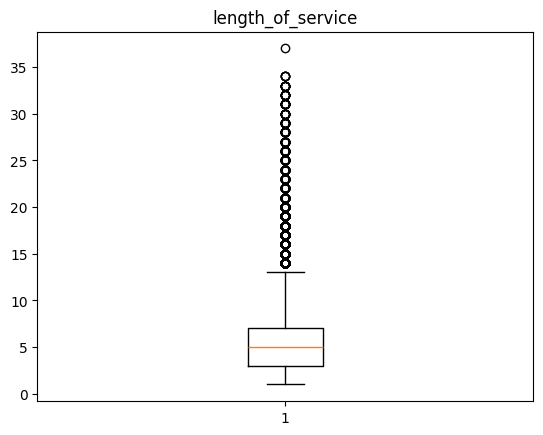

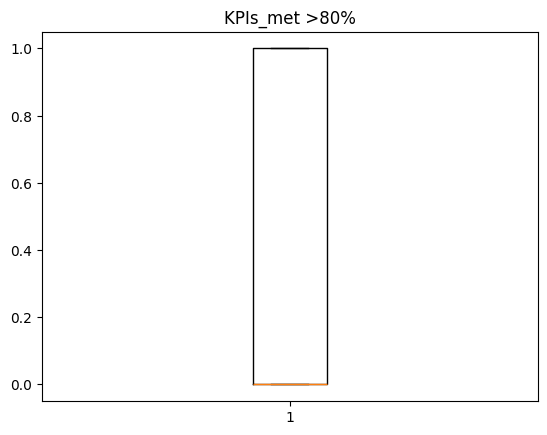

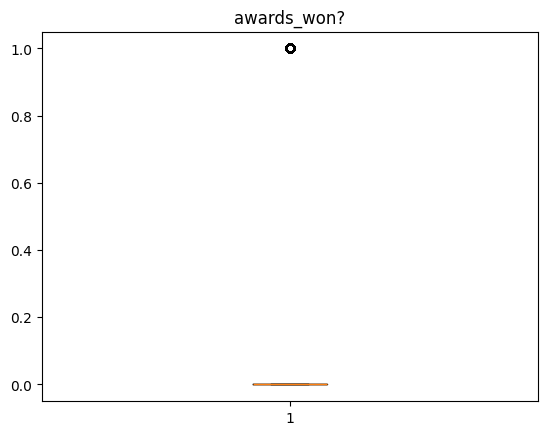

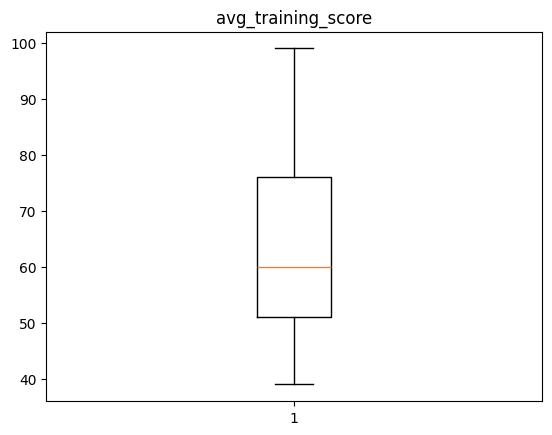

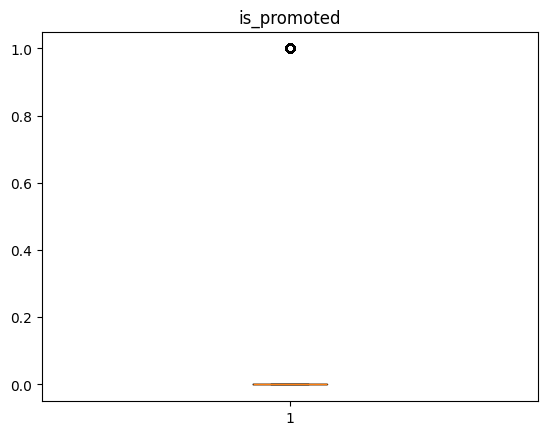

In [ ]:
columns = train_df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(train_df[i])
  plt.title(i)
  plt.show()

In [ ]:
X = train_df.drop(columns=['is_promoted', 'employee_id'])
y = train_df['is_promoted']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((43846, 12), (10962, 12), (43846,), (10962,))

In [ ]:
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(exclude=['object']).columns.tolist()

In [ ]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_columns),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_columns)
])

In [ ]:
X_train_final = preprocessor.fit_transform(X_train)

In [ ]:
X_val_final = preprocessor.transform(X_val)

logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
logistic_model.fit(
    X_train_final,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [ ]:
logistic_probability = logistic_model.predict_proba(
    X_val_final
)[:, 1]

In [ ]:
thresholds = np.arange(0.20, 0.60, 0.001)

logistic_f1_scores = []

for threshold in thresholds:
    logistic_prediction = (
        logistic_probability >= threshold
    ).astype(int)

    logistic_f1_scores.append(
        f1_score(
            y_val,
            logistic_prediction
        )
    )

In [ ]:
logistic_index = np.argmax(logistic_f1_scores)

logistic_threshold = thresholds[logistic_index]
logistic_f1 = logistic_f1_scores[logistic_index]

print("Logistic Regression Threshold:", logistic_threshold)
print("Logistic Regression F1:", logistic_f1)

Logistic Regression Threshold: 0.5990000000000004
Logistic Regression F1: 0.3929601846508944


decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
decision_tree.fit(
    X_train_final,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [ ]:
decision_probability = decision_tree.predict_proba(
    X_val_final
)[:, 1]

In [ ]:
thresholds = np.arange(0.20, 0.70, 0.001)

decision_f1_scores = []

for threshold in thresholds:
    decision_prediction = (
        decision_probability >= threshold
    ).astype(int)

    decision_f1_scores.append(
        f1_score(
            y_val,
            decision_prediction
        )
    )

In [ ]:
decision_index = np.argmax(decision_f1_scores)

decision_threshold = thresholds[decision_index]
decision_f1 = decision_f1_scores[decision_index]

print("Decision Tree Threshold:", decision_threshold)
print("Decision Tree F1:", decision_f1)

Decision Tree Threshold: 0.6880000000000004
Decision Tree F1: 0.48141377209018893


random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
random_forest.fit(
    X_train_final,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
random_forest_probability = random_forest.predict_proba(
    X_val_final
)[:, 1]

In [ ]:
thresholds = np.arange(0.20, 0.70, 0.001)

random_forest_f1_scores = []

for threshold in thresholds:
    random_forest_prediction = (
        random_forest_probability >= threshold
    ).astype(int)

    random_forest_f1_scores.append(
        f1_score(
            y_val,
            random_forest_prediction
        )
    )

In [ ]:
random_forest_index = np.argmax(
    random_forest_f1_scores
)

random_forest_threshold = thresholds[
    random_forest_index
]

random_forest_f1 = random_forest_f1_scores[
    random_forest_index
]

print(
    "Random Forest Threshold:",
    random_forest_threshold
)

print(
    "Random Forest F1:",
    random_forest_f1
)

Random Forest Threshold: 0.6260000000000003
Random Forest F1: 0.405444822557122


XG Boost Classifier

In [ ]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [ ]:
model.fit(
    X_train_final,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_probability = model.predict_proba(
    X_val_final
)[:, 1]

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.20, 0.60, 0.001)

f1_scores = []

for threshold in thresholds:
    y_prediction = (
        y_probability >= threshold
    ).astype(int)

    f1_scores.append(
        f1_score(
            y_val,
            y_prediction
        )
    )

In [ ]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.2890000000000001
Best F1 Score: 0.540222367560497


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

cat_train = X_train.copy()
cat_val = X_val.copy()

for col in categorical_columns:
    cat_train[col] = cat_train[col].fillna('Missing')
    cat_val[col] = cat_val[col].fillna('Missing')

cat_model = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    cat_features=categorical_columns,
    class_weights=[1, 3.5],
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    cat_train,
    y_train,
    eval_set=(cat_val, y_val),
    verbose=False
)

cat_probability = cat_model.predict_proba(cat_val)[:, 1]

In [ ]:
blend_probability = 0.5 * y_probability + 0.5 * cat_probability

blend_thresholds = np.arange(0.25, 0.61, 0.01)
blend_f1_scores = []

for threshold in blend_thresholds:
    blend_prediction = (blend_probability >= threshold).astype(int)
    blend_f1_scores.append(f1_score(y_val, blend_prediction))

blend_best_index = np.argmax(blend_f1_scores)
blend_best_threshold = blend_thresholds[blend_best_index]
blend_best_f1 = blend_f1_scores[blend_best_index]

print("Best Threshold:", blend_best_threshold)
print("Best F1 Score:", blend_best_f1)

Best Threshold: 0.4600000000000002
Best F1 Score: 0.5366197183098591


In [ ]:
xgb_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_final.fit(X, y)

X_test_final = test_df.drop(columns=['employee_id'])
xgb_test_probability = xgb_final.predict_proba(X_test_final)[:, 1]

In [ ]:
cat_full = X.copy()
cat_test_full = X_test_final.copy()

for col in categorical_columns:
    cat_full[col] = cat_full[col].fillna('Missing')
    cat_test_full[col] = cat_test_full[col].fillna('Missing')

In [ ]:
cat_final = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    cat_features=categorical_columns,
    class_weights=[1, 3.5],
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False
)

cat_final.fit(cat_full, y, verbose=False)

cat_test_probability = cat_final.predict_proba(cat_test_full)[:, 1]

In [ ]:
final_probability = 0.5 * xgb_test_probability + 0.5 * cat_test_probability

final_prediction = (final_probability >= blend_best_threshold).astype(int)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(X_train_final, y_train)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=5,
                           min_samples_split=10, n_estimators=300,
                           random_state=42)

In [ ]:
X_test_final = preprocessor.transform(test_df.drop(columns=['employee_id']))

In [ ]:
gb_test_prob = gb_model.predict_proba(X_test_final)[:, 1]

In [ ]:
candidate_a_prob = (
    0.35 * xgb_test_probability +
    0.45 * cat_test_probability +
    0.20 * gb_test_prob
)

candidate_a_threshold = 0.37

candidate_a_pred = (
    candidate_a_prob >= candidate_a_threshold
).astype(int)

print("CANDIDATE A")
print("Threshold:", candidate_a_threshold)
print("Predicted 0:", np.sum(candidate_a_pred == 0))
print("Predicted 1:", np.sum(candidate_a_pred == 1))
print(
    "Positive percentage:",
    round(candidate_a_pred.mean() * 100, 2),
    "%"
)

CANDIDATE A
Threshold: 0.37
Predicted 0: 22177
Predicted 1: 1313
Positive percentage: 5.59 %


In [ ]:
sample_submission = pd.read_csv('/content/drive/MyDrive/Data Science Main/Intermediate Assessment /sample_submission_M0L0uXE.csv')
candidate_a_submission = sample_submission.copy()

candidate_a_submission['is_promoted'] = candidate_a_pred

candidate_a_submission.to_csv(
    '/content/drive/MyDrive/Data Science Main/Intermediate Assessment /samplesub.csv',
    index=False
)

print("Submission saved as samplesub.csv")

Submission saved as samplesub.csv
